# Temporal Analysis for `--temporal_batch_duration`

Analyzes each dataset's timestamp distribution to guide the choice of `temporal_batch_duration`.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def temporal_analysis(csv_path: str):
    """Analyze temporal distribution of a dataset to help pick temporal_batch_duration.
    
    Loads the CSV, computes timestamp statistics, and plots:
    1. Event count over time (using various candidate durations as bin widths)
    2. Inter-event time distribution
    3. Cumulative event fraction over time
    """
    df = pd.read_csv(csv_path)
    name = Path(csv_path).stem.replace("ml_", "")
    ts = df["ts"].values
    ts_sorted = np.sort(ts)
    
    total_events = len(ts_sorted)
    ts_min, ts_max = ts_sorted[0], ts_sorted[-1]
    total_span = ts_max - ts_min
    
    # Inter-event gaps
    gaps = np.diff(ts_sorted)
    gaps_nonzero = gaps[gaps > 0]
    
    print(f"{'='*60}")
    print(f"Dataset: {name}")
    print(f"{'='*60}")
    print(f"Total events:        {total_events:,}")
    print(f"Unique users (u):    {df['u'].nunique():,}")
    print(f"Unique items (i):    {df['i'].nunique():,}")
    print(f"Timestamp range:     [{ts_min:.1f}, {ts_max:.1f}]")
    print(f"Total time span:     {total_span:.1f} seconds = {total_span/3600:.1f} hours = {total_span/86400:.1f} days")
    print()
    
    # Gap statistics
    print("Inter-event gap statistics (seconds):")
    for label, arr in [("All gaps", gaps), ("Non-zero gaps", gaps_nonzero)]:
        if len(arr) == 0:
            continue
        print(f"  {label}:")
        print(f"    min={arr.min():.4f}, median={np.median(arr):.4f}, mean={arr.mean():.4f}, max={arr.max():.4f}")
        print(f"    p25={np.percentile(arr,25):.4f}, p75={np.percentile(arr,75):.4f}, p95={np.percentile(arr,95):.4f}, p99={np.percentile(arr,99):.4f}")
    print()
    
    # Candidate durations to evaluate
    candidate_durations = {
        "1 min":     60,
        "10 min":    600,
        "1 hour":    3600,
        "6 hours":   21600,
        "1 day":     86400,
        "7 days":    604800,
        "30 days":   2592000,
    }
    # Filter to candidates that produce at least 2 bins and at most 10000 bins
    valid_candidates = {k: v for k, v in candidate_durations.items() if 2 <= total_span / v <= 10000}
    
    print("Candidate temporal_batch_duration analysis:")
    print(f"  {'Duration':<12} {'Seconds':>12} {'Num Windows':>12} {'Mean Events/Win':>18} {'Std Events/Win':>16}")
    print(f"  {'-'*70}")
    
    duration_stats = {}
    for label, dur in candidate_durations.items():
        n_windows = int(np.ceil(total_span / dur))
        if n_windows < 1:
            n_windows = 1
        bins = np.arange(ts_min, ts_max + dur, dur)
        counts, _ = np.histogram(ts_sorted, bins=bins)
        duration_stats[label] = (dur, counts)
        print(f"  {label:<12} {dur:>12.0f} {n_windows:>12,} {counts.mean():>18.1f} {counts.std():>16.1f}")
    print()
    
    # --- Plots ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Temporal Analysis: {name}", fontsize=14, fontweight="bold")
    
    # Plot 1: Event count histogram over time for select durations
    ax = axes[0, 0]
    plot_candidates = list(valid_candidates.items())
    # Pick up to 3 spread-out candidates
    if len(plot_candidates) > 3:
        indices = [0, len(plot_candidates)//2, -1]
        plot_candidates = [plot_candidates[i] for i in indices]
    for label, dur in plot_candidates:
        bins = np.arange(ts_min, ts_max + dur, dur)
        counts, edges = np.histogram(ts_sorted, bins=bins)
        bin_centers = (edges[:-1] + edges[1:]) / 2
        # Normalize x-axis to days from start
        x = (bin_centers - ts_min) / 86400
        ax.plot(x, counts, label=f"bin={label}", alpha=0.8)
    ax.set_xlabel("Days from start")
    ax.set_ylabel("Events per window")
    ax.set_title("Event counts per time window")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Inter-event gap distribution (log scale)
    ax = axes[0, 1]
    if len(gaps_nonzero) > 0:
        ax.hist(np.log10(gaps_nonzero + 1e-10), bins=100, edgecolor="black", alpha=0.7)
        ax.set_xlabel("log10(inter-event gap in seconds)")
        ax.set_ylabel("Frequency")
        ax.set_title("Inter-event gap distribution (non-zero)")
        # Mark candidate durations
        for label, dur in candidate_durations.items():
            if dur <= total_span:
                ax.axvline(np.log10(dur), color="red", linestyle="--", alpha=0.5, label=label)
        ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Cumulative event fraction
    ax = axes[1, 0]
    x = (ts_sorted - ts_min) / 86400
    y = np.arange(1, total_events + 1) / total_events
    # Subsample for plotting efficiency
    step = max(1, total_events // 5000)
    ax.plot(x[::step], y[::step], linewidth=1)
    ax.set_xlabel("Days from start")
    ax.set_ylabel("Cumulative fraction of events")
    ax.set_title("Cumulative event distribution")
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Events per window for all candidate durations (bar chart)
    ax = axes[1, 1]
    labels_list = list(candidate_durations.keys())
    means = []
    stds = []
    for label in labels_list:
        dur = candidate_durations[label]
        bins = np.arange(ts_min, ts_max + dur, dur)
        counts, _ = np.histogram(ts_sorted, bins=bins)
        means.append(counts.mean())
        stds.append(counts.std())
    x_pos = np.arange(len(labels_list))
    ax.bar(x_pos, means, yerr=stds, capsize=3, alpha=0.7, edgecolor="black")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels_list, rotation=45, ha="right")
    ax.set_ylabel("Events per window (mean ± std)")
    ax.set_title("Events per window by candidate duration")
    ax.grid(True, alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.show()
    
    print(f"Suggestion: For {name}, current scripts use 86400.0 (1 day).")
    print(f"  This yields ~{int(np.ceil(total_span / 86400))} windows with ~{total_events / max(1, np.ceil(total_span / 86400)):.0f} events/window on average.")
    print()

## Run analysis for all datasets

Found 6 datasets: ['ml_CollegeMsg', 'ml_TaobaoSmall', 'ml_enron', 'ml_mooc', 'ml_reddit', 'ml_wikipedia']

Dataset: CollegeMsg
Total events:        59,834
Unique users (u):    1,350
Unique items (i):    1,862
Timestamp range:     [1082155839.0, 1098777142.0]
Total time span:     16621303.0 seconds = 4617.0 hours = 192.4 days

Inter-event gap statistics (seconds):
  All gaps:
    min=0.0000, median=37.0000, mean=277.7949, max=258552.0000
    p25=13.0000, p75=113.0000, p95=962.8000, p99=4398.5200
  Non-zero gaps:
    min=1.0000, median=38.0000, mean=282.1522, max=258552.0000
    p25=14.0000, p75=115.0000, p95=983.0000, p99=4439.0000

Candidate temporal_batch_duration analysis:
  Duration          Seconds  Num Windows    Mean Events/Win   Std Events/Win
  ----------------------------------------------------------------------
  1 min                  60      277,022                0.2              0.7
  10 min                600       27,703                2.2              5.6
  1 hour    

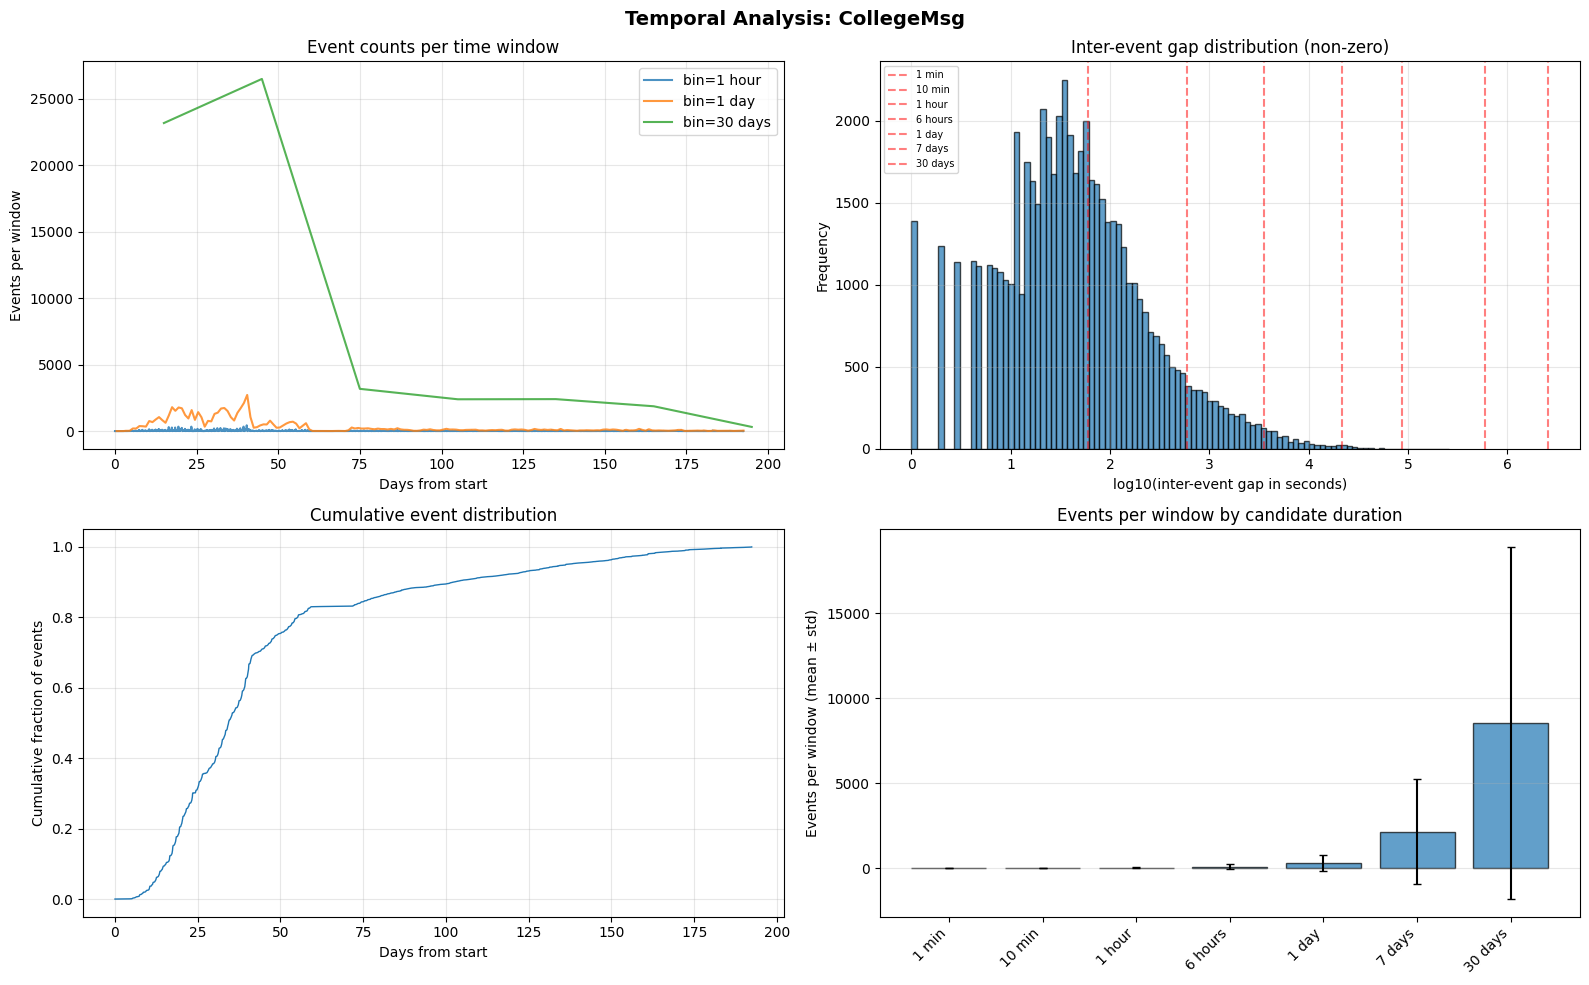

Suggestion: For CollegeMsg, current scripts use 86400.0 (1 day).
  This yields ~193 windows with ~310 events/window on average.

Dataset: TaobaoSmall
Total events:        3,867,341
Unique users (u):    450,454
Unique items (i):    964,285
Timestamp range:     [1511643600.0, 1511679600.0]
Total time span:     36000.0 seconds = 10.0 hours = 0.4 days

Inter-event gap statistics (seconds):
  All gaps:
    min=0.0000, median=0.0000, mean=0.0093, max=1.0000
    p25=0.0000, p75=0.0000, p95=0.0000, p99=0.0000
  Non-zero gaps:
    min=1.0000, median=1.0000, mean=1.0000, max=1.0000
    p25=1.0000, p75=1.0000, p95=1.0000, p99=1.0000

Candidate temporal_batch_duration analysis:
  Duration          Seconds  Num Windows    Mean Events/Win   Std Events/Win
  ----------------------------------------------------------------------
  1 min                  60          600             6445.6           2710.4
  10 min                600           60            64455.7          27082.2
  1 hour             

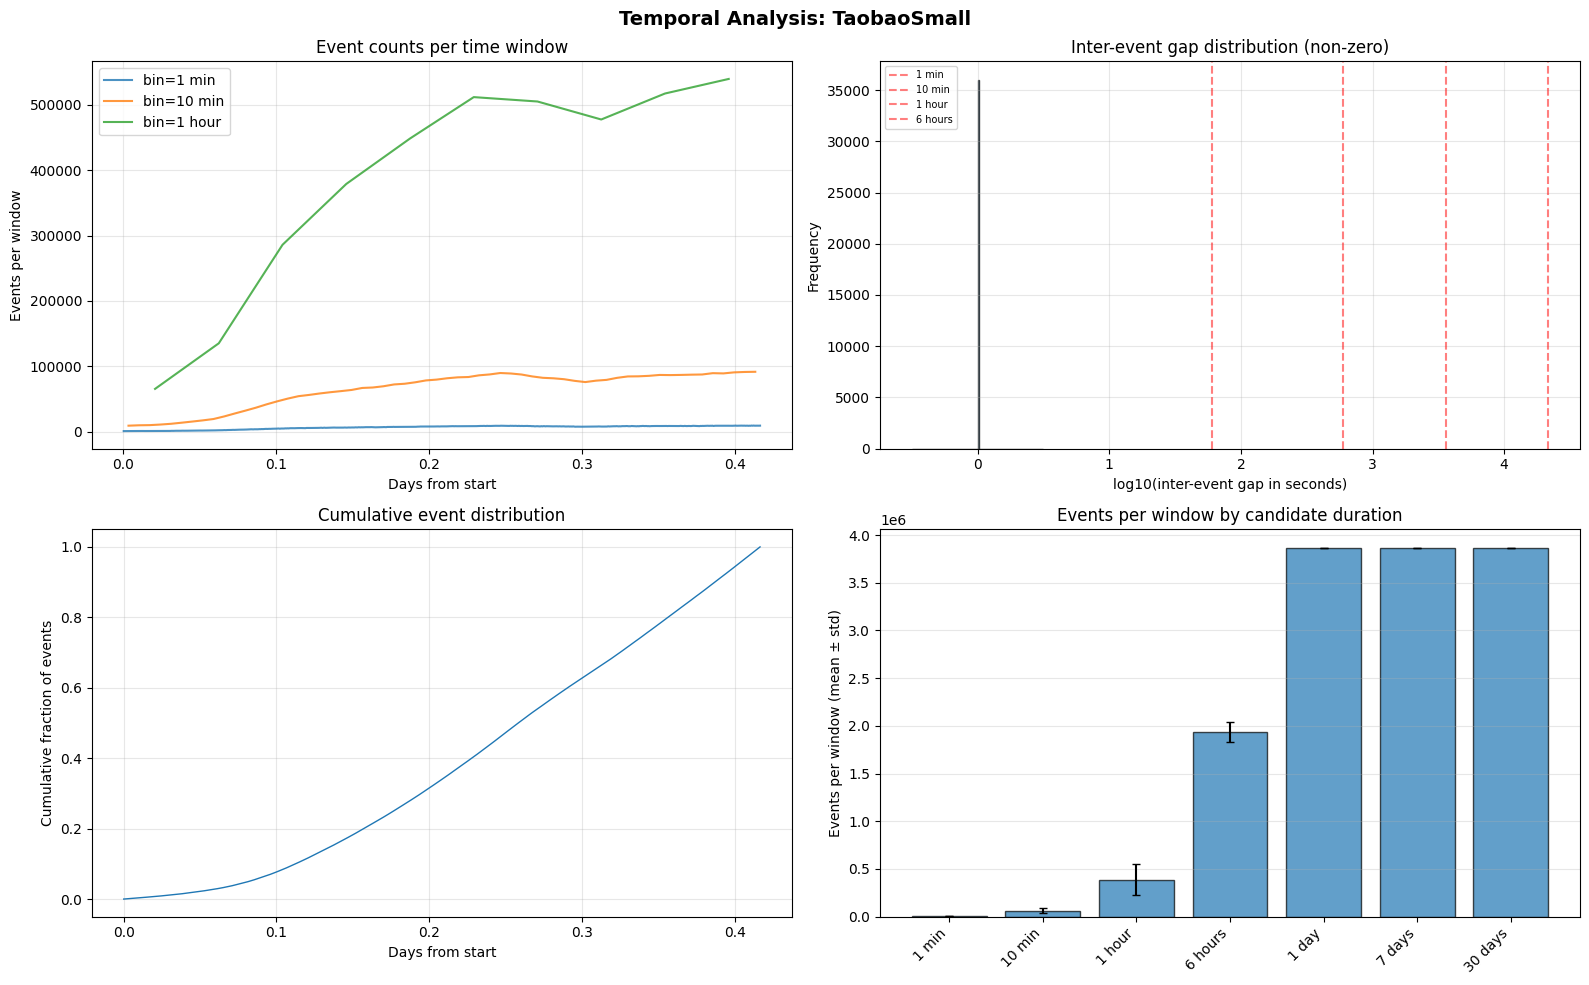

Suggestion: For TaobaoSmall, current scripts use 86400.0 (1 day).
  This yields ~1 windows with ~3867341 events/window on average.

Dataset: enron
Total events:        125,235
Unique users (u):    181
Unique items (i):    184
Timestamp range:     [0.0, 113740399.0]
Total time span:     113740399.0 seconds = 31594.6 hours = 1316.4 days

Inter-event gap statistics (seconds):
  All gaps:
    min=0.0000, median=0.0000, mean=908.2230, max=1804800.0000
    p25=0.0000, p75=0.0000, p95=1840.3500, p99=12820.2000
  Non-zero gaps:
    min=1.0000, median=753.0000, mean=5025.8671, max=1804800.0000
    p25=253.0000, p75=2058.5000, p95=15125.0000, p99=75816.1000

Candidate temporal_batch_duration analysis:
  Duration          Seconds  Num Windows    Mean Events/Win   Std Events/Win
  ----------------------------------------------------------------------
  1 min                  60    1,895,674                0.1              1.9
  10 min                600      189,568                0.7             

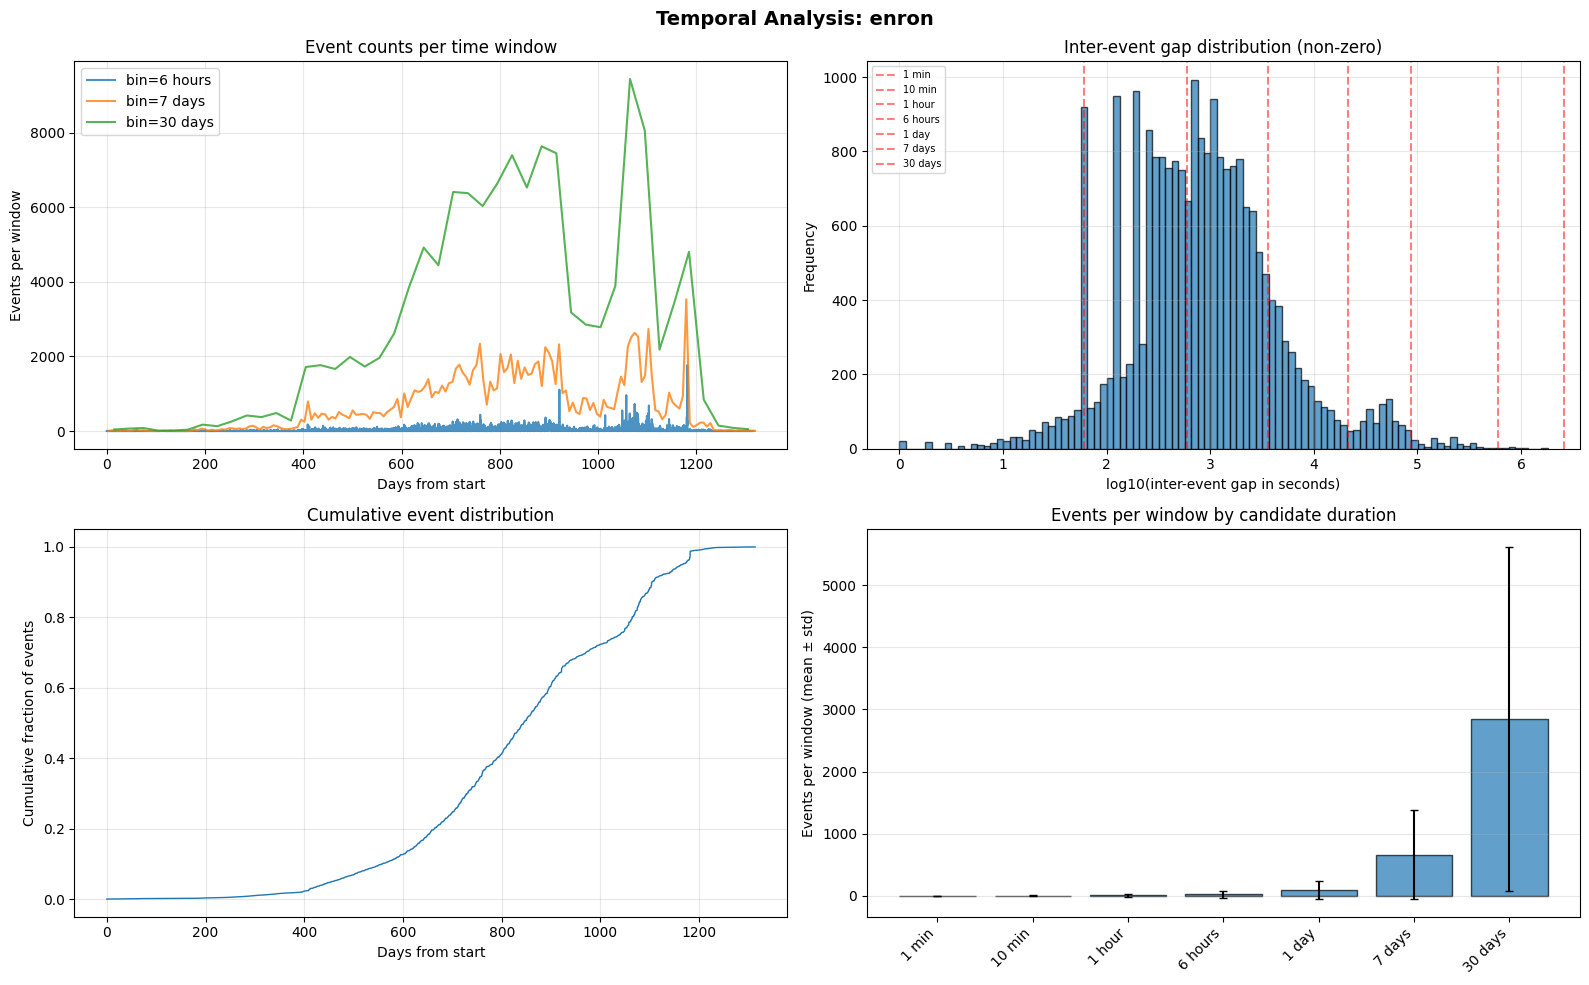

Suggestion: For enron, current scripts use 86400.0 (1 day).
  This yields ~1317 windows with ~95 events/window on average.

Dataset: mooc
Total events:        411,749
Unique users (u):    7,047
Unique items (i):    97
Timestamp range:     [0.0, 2572086.0]
Total time span:     2572086.0 seconds = 714.5 hours = 29.8 days

Inter-event gap statistics (seconds):
  All gaps:
    min=0.0000, median=2.0000, mean=6.2467, max=30022.0000
    p25=1.0000, p75=5.0000, p95=18.0000, p99=53.0000
  Non-zero gaps:
    min=1.0000, median=3.0000, mean=7.4424, max=30022.0000
    p25=1.0000, p75=6.0000, p95=20.0000, p99=61.0000

Candidate temporal_batch_duration analysis:
  Duration          Seconds  Num Windows    Mean Events/Win   Std Events/Win
  ----------------------------------------------------------------------
  1 min                  60       42,869                9.6              9.8
  10 min                600        4,287               96.0             85.6
  1 hour               3600          7

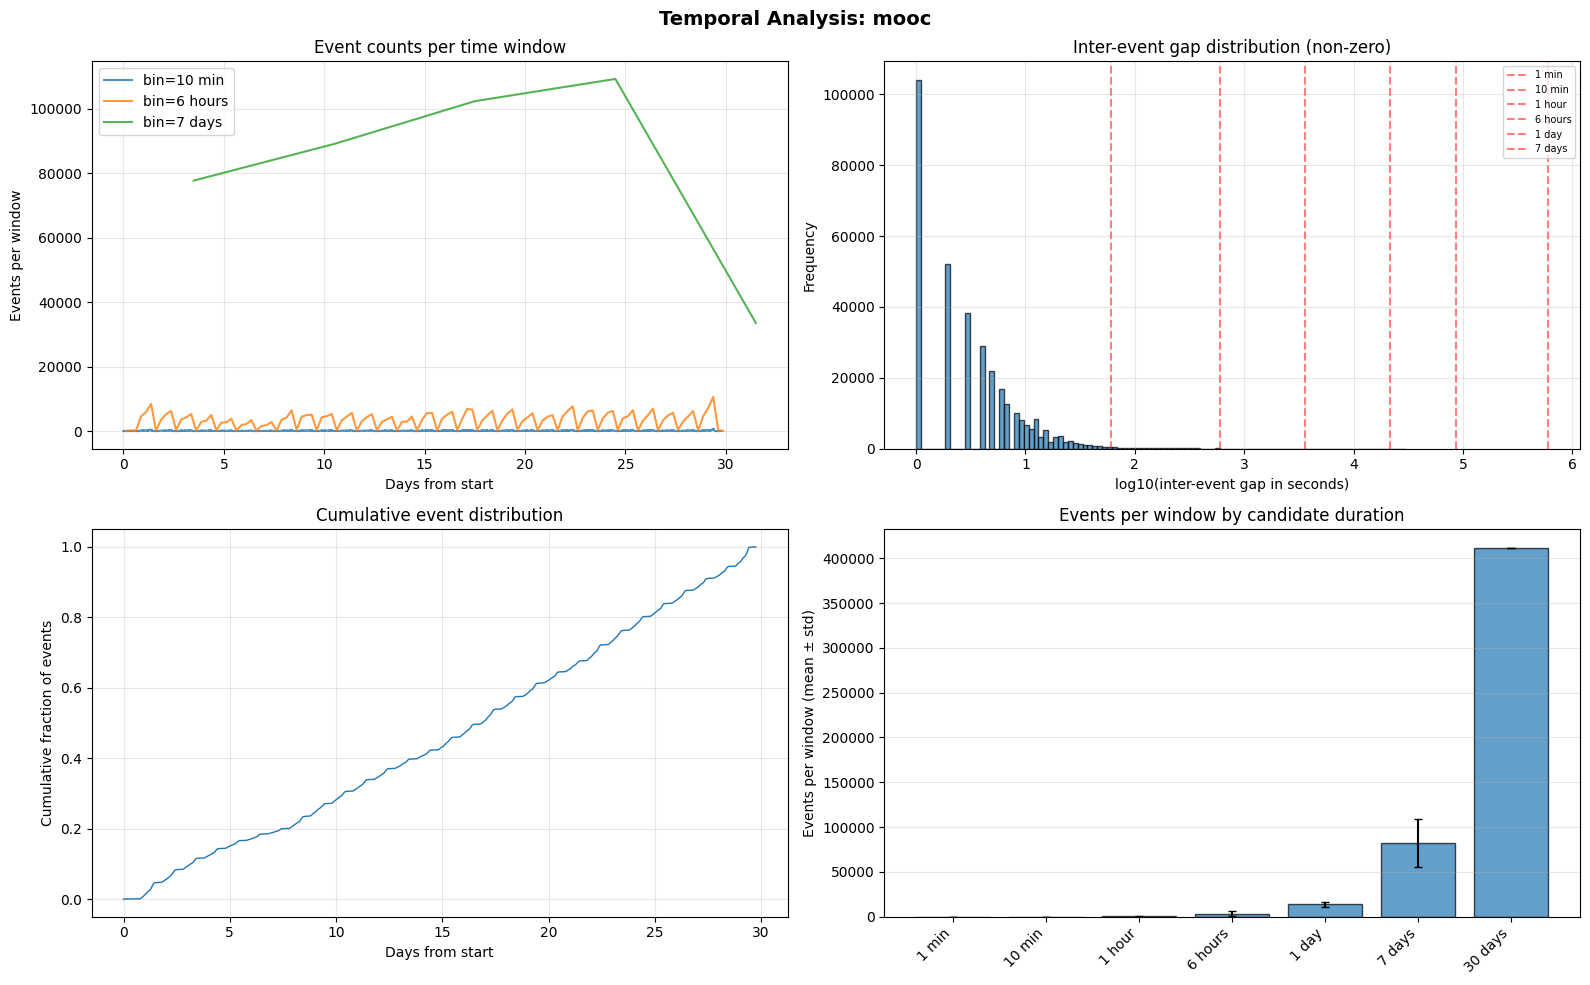

Suggestion: For mooc, current scripts use 86400.0 (1 day).
  This yields ~30 windows with ~13725 events/window on average.

Dataset: reddit
Total events:        672,447
Unique users (u):    10,000
Unique items (i):    984
Timestamp range:     [0.0, 2678390.0]
Total time span:     2678390.0 seconds = 744.0 hours = 31.0 days

Inter-event gap statistics (seconds):
  All gaps:
    min=0.0000, median=2.6450, mean=3.9831, max=77.4110
    p25=1.0880, p75=5.4270, p95=12.3190, p99=19.8351
  Non-zero gaps:
    min=0.0010, median=2.6660, mean=4.0032, max=77.4110
    p25=1.1030, p75=5.4480, p95=12.3410, p99=19.8580

Candidate temporal_batch_duration analysis:
  Duration          Seconds  Num Windows    Mean Events/Win   Std Events/Win
  ----------------------------------------------------------------------
  1 min                  60       44,640               15.1              5.3
  10 min                600        4,464              150.6             37.2
  1 hour               3600          744

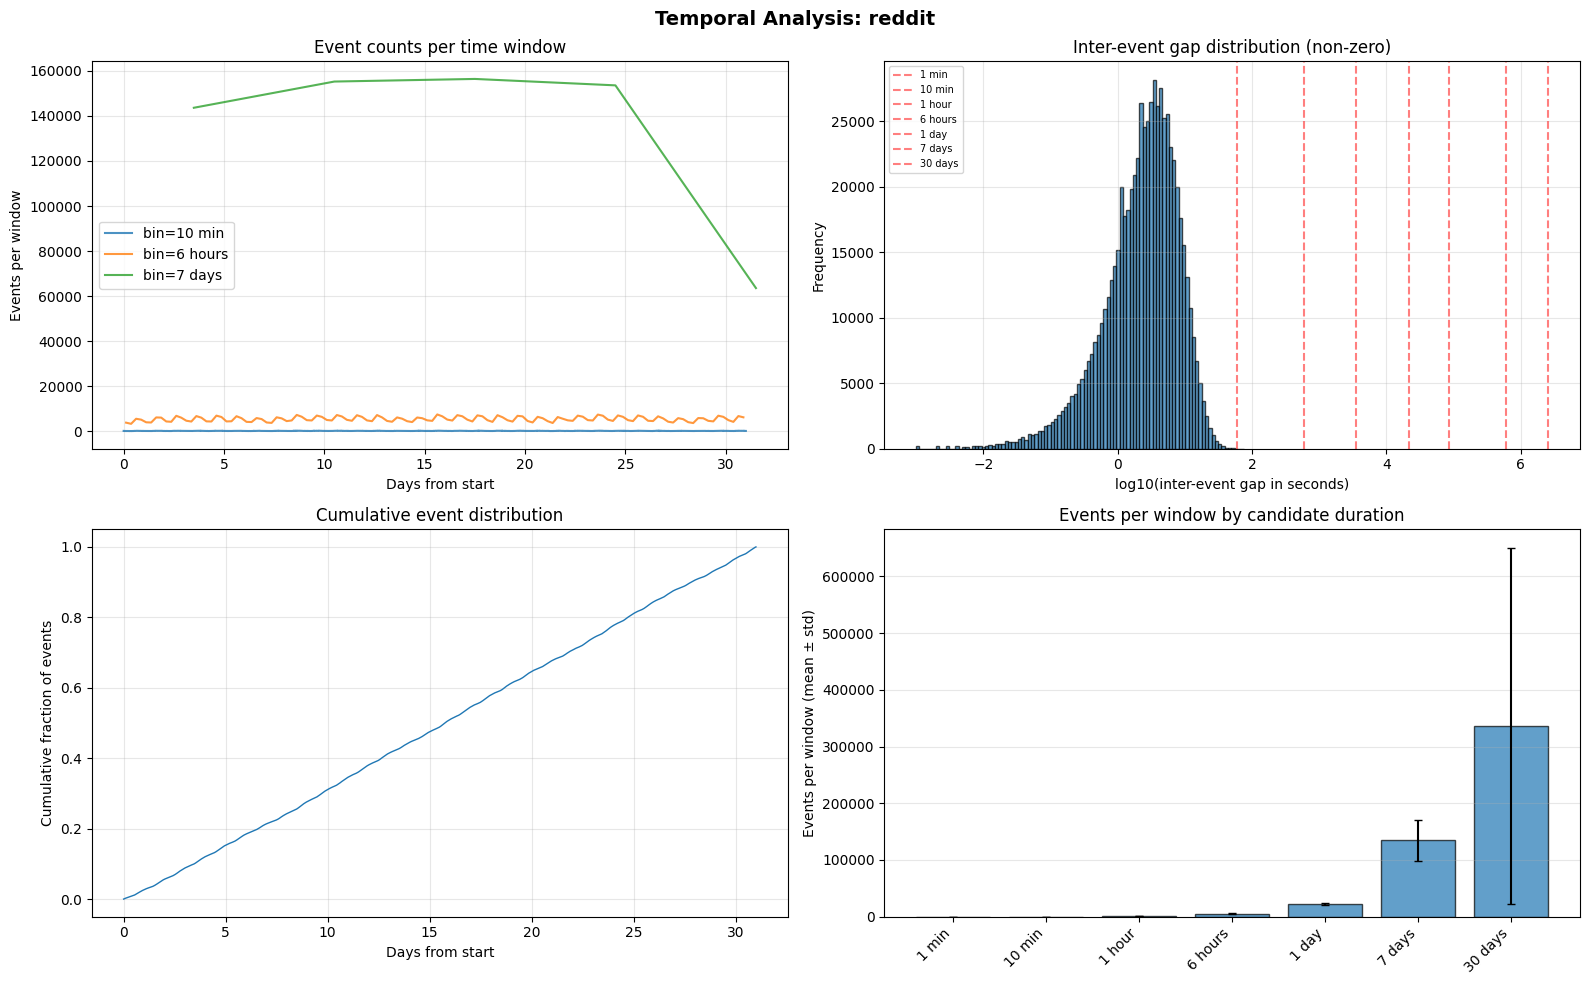

Suggestion: For reddit, current scripts use 86400.0 (1 day).
  This yields ~31 windows with ~21692 events/window on average.

Dataset: wikipedia
Total events:        157,474
Unique users (u):    8,227
Unique items (i):    1,000
Timestamp range:     [0.0, 2678373.0]
Total time span:     2678373.0 seconds = 744.0 hours = 31.0 days

Inter-event gap statistics (seconds):
  All gaps:
    min=0.0000, median=11.0000, mean=17.0085, max=454.0000
    p25=5.0000, p75=23.0000, p95=52.0000, p99=87.0000
  Non-zero gaps:
    min=1.0000, median=12.0000, mean=17.5337, max=454.0000
    p25=5.0000, p75=23.0000, p95=52.0000, p99=88.0000

Candidate temporal_batch_duration analysis:
  Duration          Seconds  Num Windows    Mean Events/Win   Std Events/Win
  ----------------------------------------------------------------------
  1 min                  60       44,640                3.5              2.1
  10 min                600        4,464               35.3             12.1
  1 hour               360

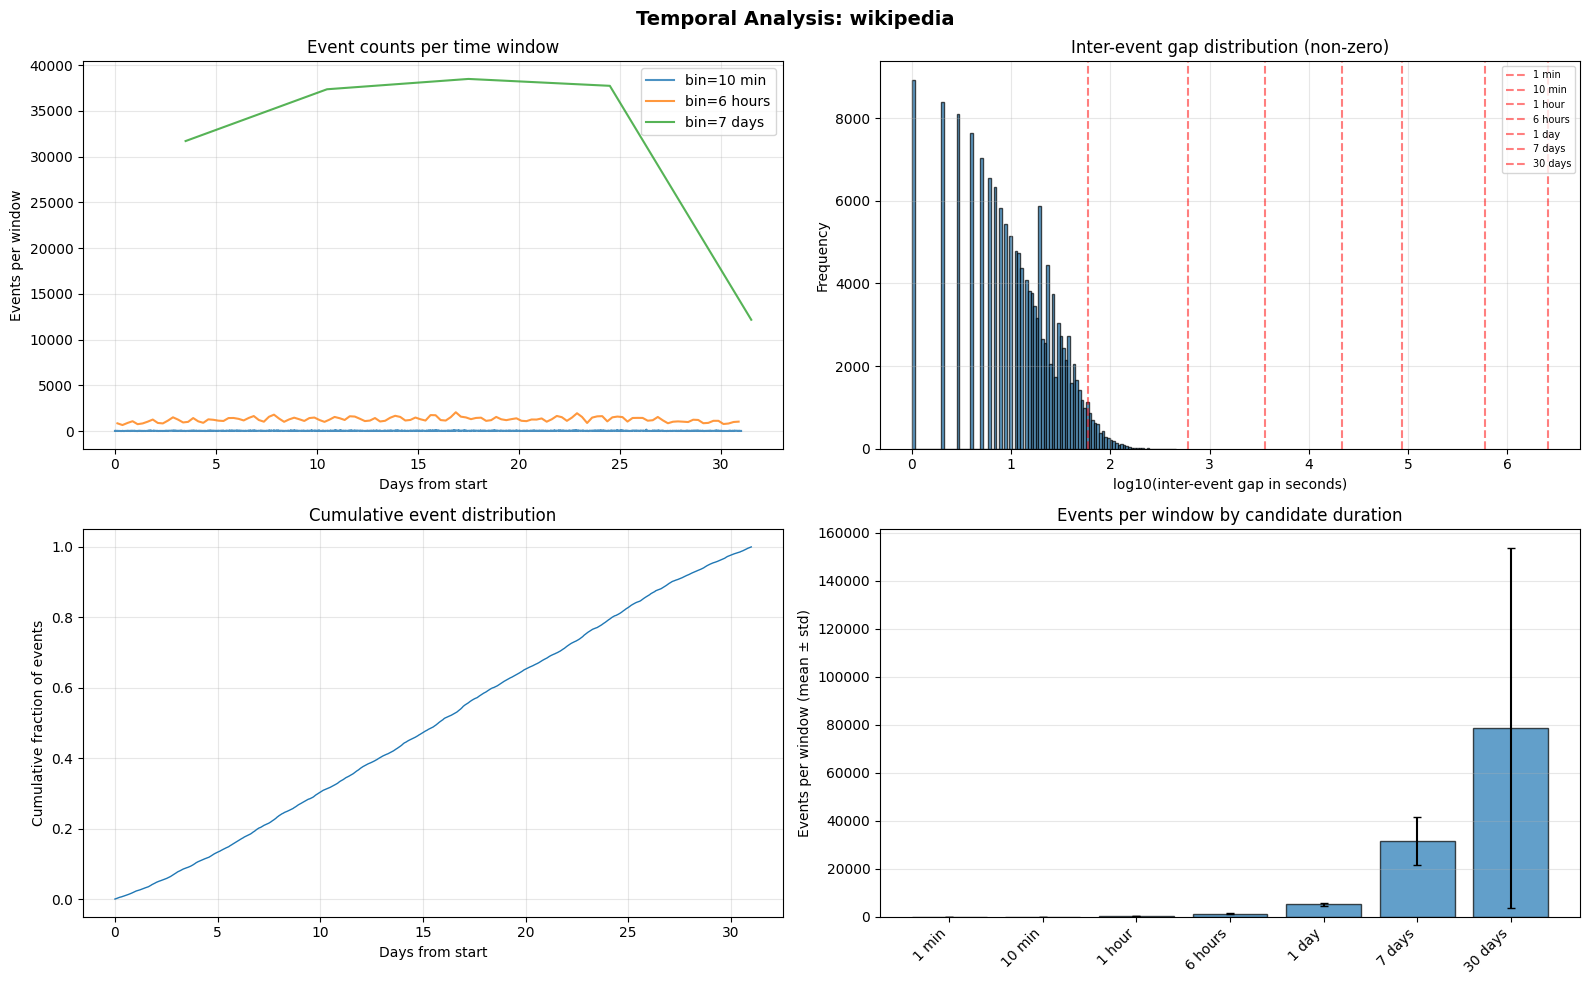

Suggestion: For wikipedia, current scripts use 86400.0 (1 day).
  This yields ~31 windows with ~5080 events/window on average.



In [5]:
csv_files = sorted(Path(".").glob("ml_*.csv"))
print(f"Found {len(csv_files)} datasets: {[f.stem for f in csv_files]}\n")

for csv_path in csv_files:
    temporal_analysis(str(csv_path))